# CNN示例

演示使用CNN识别病原细菌Raman光谱. 以下改编自“Rapid identification of pathogenic bacteria using Raman spectroscopy and deep learning”论文结果的[代码库bacteria-ID](https://github.com/csho33/bacteria-ID)。

## 依赖包
- Python 3.12
- PyTorch # 开源深度学习库，广泛用于计算机视觉和自然语言处理等应用
- Scikit-Learn
- Numpy 
- Jupyter 
- Seaborn 
- Matplotlib  
注：使用与Python版本配套的最新版本 

## 数据说明

尊重原作成果，实验数据可以从论文项目所提供网盘[下载](https://www.dropbox.com/sh/gmgduvzyl5tken6/AABtSWXWPjoUBkKyC2e7Ag6Da?dl=0)，并应保存于本项目data子目录中。
各文件如下：
* wavenumbers.npy : The wavenumbers of all spectra.
* X_reference.npy,y_refence.npy : reference spectra and their isolate-level labels.
* X_finetune.npy,y_finetune.npy : spectra used for finetuning and their isolate-level labels.
* X_test.npy,y_test.npy : spectra used for testing and their isolate-level labels.
* X_2018clinical.npy,y_2018clinical.npy,X_2019clinical.npy,y_2019clinical.npy : clinical spectra and their antibiotic-level labels.

## 一、训练

**torch.nn** 是PyTorch中用于构建神经网络的模块。它提供了一系列的类和函数，用于构建、训练和评估深度学习模型。以下是 torch.nn 的一些主要作用和特点：
* 构建网络层：
  torch.nn 提供了多种预定义的神经网络层，如线性层（nn.Linear）、卷积层（nn.Conv2d, nn.Conv1d）、池化层（nn.MaxPool2d, nn.MaxPool1d）、归一化层（nn.BatchNorm2d, nn.BatchNorm1d）等。
* 定义损失函数：
  torch.nn 包含了多种损失函数，如均方误差（nn.MSELoss）、交叉熵损失（nn.CrossEntropyLoss）、二元交叉熵损失（nn.BCELoss）等，这些损失函数用于训练过程中计算预测值和真实值之间的差异。
* 实现激活函数：
  torch.nn 提供了多种激活函数，如 ReLU（nn.ReLU）、sigmoid（nn.Sigmoid）、tanh（nn.Tanh）等，这些函数用于在神经网络中引入非线性。
* 构建自定义层：
  用户可以通过继承 nn.Module 类来创建自定义的网络层或整个模型。
* 模块化设计：
  torch.nn 支持模块化设计，允许用户将复杂的模型分解为多个子模块，这些子模块可以是预定义的层或者自定义的模块。
* 参数管理：
  torch.nn 中的 nn.Module 类自动管理其子模块的参数，使得参数的初始化、更新和保存变得简单。
* 前向传播：
  在 nn.Module 类中定义 forward 方法来指定模型的前向传播路径，PyTorch 会自动处理梯度的反向传播。
* 序列化：
  torch.nn 提供了方便的方法来保存和加载整个模型或单独的权重。
* 优化器接口：
  虽然 torch.optim 模块提供了优化器，但 torch.nn 与之紧密集成，用于在训练过程中更新模型的参数。
* 包装器和实用工具：
  torch.nn 还提供了一些包装器（如 nn.Dropout、nn.ReLU）和实用工具（如 nn.functional），用于实现特定的功能。


**以下内容为git仓库中"resnet.py"(项目模型)文件内容。**  

In [3]:
# 构建残差网络RESNET
import torch
import torch.nn as nn
import torch.nn.functional as F
# from torch.autograd import Variable  # torch.autograd 是 PyTorch 中用于自动求导的关键模块,提供了自动计算梯度的机制

# 构建残差块
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # Layers
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=5,
            stride=stride, padding=2, dilation=1, bias=False)                        # 1d的卷积
        # 上面之所以用1d是因为输入数据的结构在dataset.py中被转换为[C, L] 2维数据，而卷积时不考虑channel，因此就剩下1维。 
        
        self.bn1 = nn.BatchNorm1d(num_features=out_channels)                         # 1d的批标准化
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=5,
            stride=1, padding=2, dilation=1, bias=False)
        self.bn2 = nn.BatchNorm1d(num_features=out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1,
                    stride=stride, bias=False),
                nn.BatchNorm1d(out_channels))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        # print('out_size:', out.size())
        out = self.bn2(self.conv2(out))
        # print('shortcut:', self.shortcut(x).size())
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, hidden_sizes, num_blocks, input_dim=1000,
        in_channels=64, n_classes=30):
        super(ResNet, self).__init__()
        assert len(num_blocks) == len(hidden_sizes)
        self.input_dim = input_dim
        self.in_channels = in_channels
        self.n_classes = n_classes
        
        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=5, stride=1,
            padding=2, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        
        # Flexible number of residual encoding layers
        layers = []
        strides = [1] + [2] * (len(hidden_sizes) - 1)
        for idx, hidden_size in enumerate(hidden_sizes):
            layers.append(self._make_layer(hidden_size, num_blocks[idx],
                stride=strides[idx]))
        self.encoder = nn.Sequential(*layers)

        self.z_dim = self._get_encoding_size()
        self.linear = nn.Linear(self.z_dim, self.n_classes)


    def encode(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.encoder(x)
        z = x.view(x.size(0), -1)
        return z

    def forward(self, x):
        z = self.encode(x)
        return self.linear(z)


    def _make_layer(self, out_channels, num_blocks, stride=1):
        strides = [stride] + [1] * (num_blocks - 1)
        # strides = [stride]
        blocks = []
        for stride in strides:
            blocks.append(ResidualBlock(self.in_channels, out_channels,
                stride=stride))
            self.in_channels = out_channels
        return nn.Sequential(*blocks)

    def _get_encoding_size(self):
        """
        Returns the dimension of the encoded input.
        """        
        # temp = Variable(torch.rand(1, 1, self.input_dim)) # Pytorch旧版本0.4.0，需要使用Variable包装Tensor实现自动梯度
        temp = torch.rand(1, 1, self.input_dim, requires_grad=True) 
        z = self.encode(temp)
        z_dim = z.data.size(1)
        return z_dim

#激活函数选择
def add_activation(activation='relu'):
    """
    Adds specified activation layer, choices include:
    - 'relu'
    - 'elu' (alpha)
    - 'selu'
    - 'leaky relu' (negative_slope)
    - 'sigmoid'
    - 'tanh'
    - 'softplus' (beta, threshold)
    """
    if activation == 'relu':
        return nn.ReLU()
    elif activation == 'elu':
        return nn.ELU(alpha=1.0)
    elif activation == 'selu':
        return nn.SELU()
    elif activation == 'leaky relu':
        return nn.LeakyReLU(negative_slope=0.1)
    elif activation == 'sigmoid':
        return nn.Sigmoid()
    elif activation == 'tanh':
        return nn.Tanh()
    # SOFTPLUS DOESN'T WORK with automatic differentiation in pytorch
    elif activation == 'softplus':
        return nn.Softplus(beta=1, threshold=20)

In [26]:
import numpy as np

# 数据读取
X_T = './data/X_reference.npy'
y_T = './data/y_reference.npy'
X_fn = './data/X_finetune.npy'
y_fn = './data/y_finetune.npy'
X = np.load(X_T)
y = np.load(y_T)
X1 = np.load(X_fn)
y1 = np.load(y_fn)
print(X.shape, y.shape)
print(X1.shape, y1.shape)

# 数据集分割
p_val = 0.1
n_val = int(60000 * p_val)
idx_tr = list(range(60000))
np.random.shuffle(idx_tr)
idx_val = idx_tr[:n_val]
idx_tr = idx_tr[n_val:]

(60000, 1000) (60000,)
(3000, 1000) (3000,)


In [28]:
# CNN parameters
layers = 6
hidden_size = 100
block_size = 2
hidden_sizes = [hidden_size] * layers
num_blocks = [block_size] * layers
input_dim = 1000
in_channels = 64
n_classes = 30
# os.environ['CUDA_VISIBLE_DEVICES'] = '{}'.format(0)
cuda = torch.cuda.is_available()

In [29]:
cnn = ResNet(hidden_sizes, num_blocks, input_dim=input_dim,
                in_channels=in_channels, n_classes=n_classes)  # 使用上面的模型参数创建模型

**导入依赖包**

In [1]:
from datasets import spectral_dataloader   # CNN训练、预测时加载数据
from training import run_epoch             # 本项目模型训练时function(运行一个epoch)
from torch import optim                    # 导入torch中优化器

from time import time                      # 导入时间相关包

以下训练代码不属于作者的原git仓库，作者只给出了训练好的模型，只给出结果， 但没有给出训练过程的代码。**由于reference数据集比较大，有60000行，1000个feature， 30个分类，所以有400M，训练过程比较慢，需要在GPU上运行** 微调数据集finetune只有3000行，可以在本地电脑上运行

In [31]:
best_model_path = './best_model.pth'
if cuda:
    cnn = cnn.cuda()
epochs = 30        #轮次
batch_size = 200   #样本量
t0 = time()
# Set up Adam optimizer  优化器的选择
optimizer = optim.Adam(cnn.parameters(), lr=1e-3, betas=(0.5, 0.999))  #lr学习率
# Set up dataloaders
dl_tr = spectral_dataloader(X, y, idxs=idx_tr,batch_size=batch_size, shuffle=True)
dl_val = spectral_dataloader(X, y, idxs=idx_val,batch_size=batch_size, shuffle=False)
best_val = 0
no_improvement = 0
max_no_improvement = 5
print('Starting training!')
for epoch in range(epochs):
    print(' Epoch {}: {:0.2f}s'.format(epoch+1, time()-t0))
    # Train
    acc_tr, loss_tr = run_epoch(epoch, cnn, dl_tr, cuda,training=True, optimizer=optimizer)
    print('  Train acc: {:0.2f}'.format(acc_tr))
    # Val
    acc_val, loss_val = run_epoch(epoch, cnn, dl_val, cuda,training=False, optimizer=optimizer)
    print('  Val acc  : {:0.2f}'.format(acc_val))
    # Check performance for early stopping
    if acc_val > best_val or epoch == 0:
        best_val = acc_val
        no_improvement = 0
        torch.save(cnn.state_dict(), best_model_path)
    else:
        no_improvement += 1
    if no_improvement >= max_no_improvement:
        print('Finished after {} epochs!'.format(epoch+1))
        break

Starting training!
 Epoch 1: 0.00s
  Train acc: 78.95
  Val acc  : 82.13
 Epoch 2: 37.56s
  Train acc: 91.88
  Val acc  : 82.68
 Epoch 3: 74.73s
  Train acc: 93.30
  Val acc  : 93.37
 Epoch 4: 112.05s
  Train acc: 94.37
  Val acc  : 92.67
 Epoch 5: 149.98s
  Train acc: 95.13
  Val acc  : 93.03
 Epoch 6: 187.47s
  Train acc: 95.53
  Val acc  : 93.40
 Epoch 7: 226.36s
  Train acc: 96.09
  Val acc  : 93.50
 Epoch 8: 263.90s
  Train acc: 96.45
  Val acc  : 93.37
 Epoch 9: 302.66s
  Train acc: 96.77
  Val acc  : 93.15
 Epoch 10: 341.46s
  Train acc: 95.62
  Val acc  : 92.72
 Epoch 11: 379.16s
  Train acc: 96.48
  Val acc  : 94.15
 Epoch 12: 416.76s
  Train acc: 97.65
  Val acc  : 94.22
 Epoch 13: 454.71s
  Train acc: 98.01
  Val acc  : 93.72
 Epoch 14: 492.95s
  Train acc: 98.24
  Val acc  : 93.27
 Epoch 15: 530.70s
  Train acc: 98.39
  Val acc  : 93.63
 Epoch 16: 568.36s
  Train acc: 98.37
  Val acc  : 92.73
 Epoch 17: 606.01s
  Train acc: 98.56
  Val acc  : 92.72
Finished after 17 epochs!

## 二、微调
在bacteria-ID项目中，作者没有给出如何训练模型的代码，但给出了模型训练后的结果“pretrained_model.ckpt”（该结果应该使用reference数据训练）。原代码直接使用此模型结果结合finetune数据集对模型进行微调。下面代码来源于git仓库中"1_reference_finetuning.ipynb"。

In [24]:
from time import time
t00 = time()
import numpy as np

from datasets import spectral_dataloader
from training import run_epoch
from torch import optim

In [9]:
# 加载预训练的模型（创建模型，加载预训练模型权重）
cnn = ResNet(hidden_sizes, num_blocks, input_dim=input_dim,
                in_channels=in_channels, n_classes=n_classes)
if cuda: cnn.cuda()
cnn.load_state_dict(torch.load(
    './pretrained_model.ckpt', map_location=lambda storage, loc: storage))  # 从预训练好的模型中载入参数

# 数据集分割
p_val = 0.1
n_val = int(3000 * p_val)
idx_tr = list(range(3000))
np.random.shuffle(idx_tr)
idx_val = idx_tr[:n_val]
idx_tr = idx_tr[n_val:]

epochs = 30    # 运行的总epoch数
batch_size = 10  # 每批次给定的样本数据量
t0 = time()      # t0时刻标记(用于计算运行步骤的耗时)

# 初始化Adam优化器
optimizer = optim.Adam(cnn.parameters(), lr=1e-3, betas=(0.5, 0.999))
# 初始化数据加载器(dataloaders)
dl_tr = spectral_dataloader(X1, y1, idxs=idx_tr,
    batch_size=batch_size, shuffle=True)
dl_val = spectral_dataloader(X1, y1, idxs=idx_val,
    batch_size=batch_size, shuffle=False)

# Fine-tune CNN for first fold
best_val = 0
no_improvement = 0       # 未提升轮次计数器
max_no_improvement = 5   # 最大未提升轮次数(阈值，如：5轮没有提升则跳出循环)
print('Starting fine-tuning!')
for epoch in range(epochs):
    print(' Epoch {}: {:0.2f}s'.format(epoch+1, time()-t0))
    # Train
    acc_tr, loss_tr = run_epoch(epoch, cnn, dl_tr, cuda,
        training=True, optimizer=optimizer)
    print('  Train acc: {:0.2f}'.format(acc_tr))
    # Val
    acc_val, loss_val = run_epoch(epoch, cnn, dl_val, cuda,
        training=False, optimizer=optimizer)
    print('  Val acc  : {:0.2f}'.format(acc_val))
    # Check performance for early stopping
    if acc_val > best_val or epoch == 0:
        best_val = acc_val
        no_improvement = 0
    else:
        no_improvement += 1
    if no_improvement >= max_no_improvement:
        print('Finished after {} epochs!'.format(epoch+1))
        break

print('\n This demo was completed in: {:0.2f}s'.format(time()-t00))

Starting fine-tuning!
 Epoch 1: 0.00s
  Train acc: 77.81
  Val acc  : 87.00
 Epoch 2: 23.48s
  Train acc: 90.11
  Val acc  : 90.67
 Epoch 3: 46.86s
  Train acc: 94.07
  Val acc  : 92.67
 Epoch 4: 70.16s
  Train acc: 96.07
  Val acc  : 93.33
 Epoch 5: 93.52s
  Train acc: 97.67
  Val acc  : 92.00
 Epoch 6: 116.90s
  Train acc: 98.59
  Val acc  : 92.33
 Epoch 7: 140.01s
  Train acc: 99.33
  Val acc  : 91.67
 Epoch 8: 163.43s
  Train acc: 99.52
  Val acc  : 94.33
 Epoch 9: 186.39s
  Train acc: 99.67
  Val acc  : 94.00
 Epoch 10: 209.79s
  Train acc: 99.59
  Val acc  : 90.33
 Epoch 11: 233.03s
  Train acc: 99.56
  Val acc  : 94.00
 Epoch 12: 256.07s
  Train acc: 99.81
  Val acc  : 92.33
 Epoch 13: 279.58s
  Train acc: 99.48
  Val acc  : 93.67
Finished after 13 epochs!

 This demo was completed in: 679.11s


## 三、预测
### 3.1 预测
使用上面微调好的resnet模型在测试集上进行预测。下面代码来源于git仓库中"2_reference_prediction.ipynb"。

In [2]:
from time import time
t00 = time()
import numpy as np

In [33]:
# 数据读取
X_fn = './data/X_test.npy'
y_fn = './data/y_test.npy'
X = np.load(X_fn)
y = np.load(y_fn)
print(X.shape, y.shape)

(3000, 1000) (3000,)


In [34]:
from training import get_predictions
from datasets import spectral_dataloader

In [35]:
# Make predictions on subset of data
t0 = time()
dl = spectral_dataloader(X, y, batch_size=10, shuffle=False)
y_hat = get_predictions(cnn, dl, cuda)
print('Predicted {} spectra: {:0.2f}s'.format(len(y_hat), time()-t0))

Predicted 3000 spectra: 11.28s


In [36]:
# Computing accuracy
acc = (y_hat == y).mean()
print('Accuracy: {:0.1f}%'.format(100*acc))

Accuracy: 52.7%


### 3.2 结果呈现
#### 3.2.1 所有分类标签混淆矩阵图

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 本项目目录config.py文件中的ORDER变量(序号数组，confusion_matrix作图时使用)与STRAINS变量(菌株名称的字典)
from config import ORDER, STRAINS

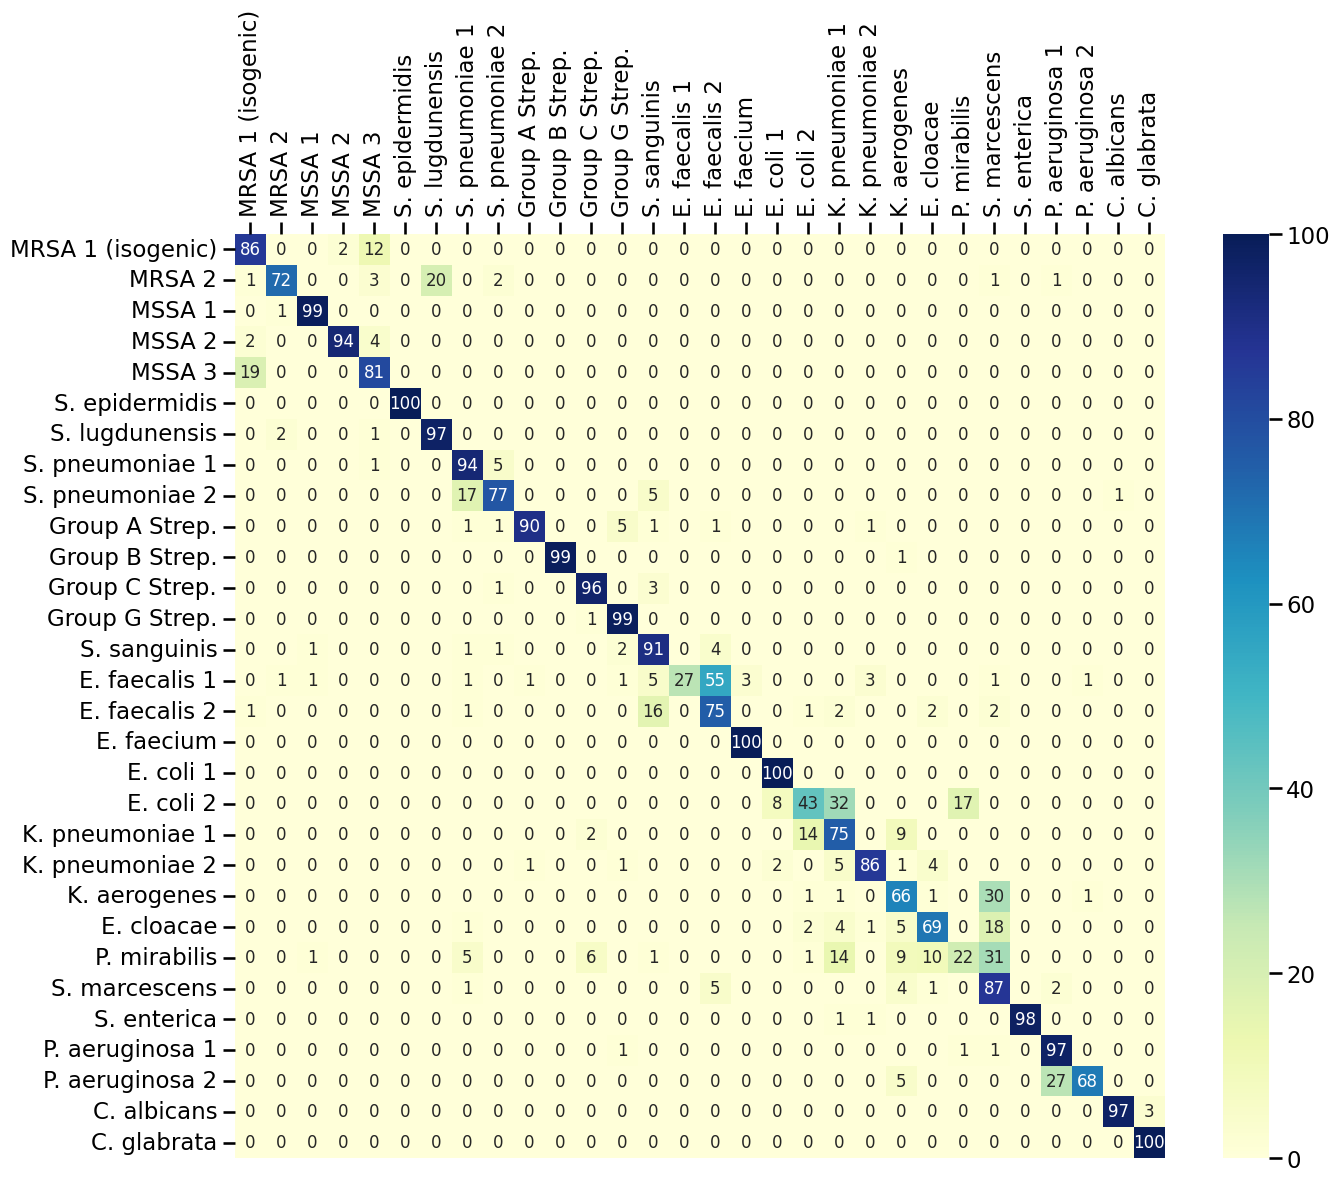

In [34]:
# Plot confusion matrix
sns.set_context("talk", rc={"font":"Helvetica", "font.size":12})
label = [STRAINS[i] for i in ORDER]
cm = confusion_matrix(y, y_hat, labels=ORDER)
plt.figure(figsize=(15, 12))
cm = 100 * cm / cm.sum(axis=1)[:,np.newaxis]
ax = sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='0.0f',
                 xticklabels=label, yticklabels=label)    # cm方阵(所有分类标签)热力图
ax.xaxis.tick_top()
plt.xticks(rotation=90) 
plt.show()

#### 3.2.2 抗生素分组标签混淆矩阵作图

In [35]:
from config import ATCC_GROUPINGS, antibiotics, ab_order

In [36]:
# Mapping predictions into antibiotic groupings
y_ab = np.asarray([ATCC_GROUPINGS[i] for i in y])
y_ab_hat = np.asarray([ATCC_GROUPINGS[i] for i in y_hat])

# Computing accuracy
acc = (y_ab_hat == y_ab).mean()
print('Accuracy: {:0.1f}%'.format(100*acc))

Accuracy: 97.5%


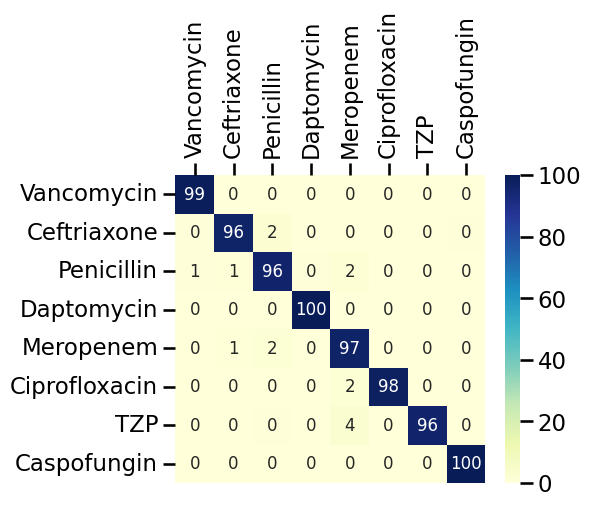


 This demo was completed in: 143.44s


In [37]:
sns.set_context("talk", rc={"font":"Helvetica", "font.size":12})
label = [antibiotics[i] for i in ab_order]
cm = confusion_matrix(y_ab, y_ab_hat, labels=ab_order)
plt.figure(figsize=(5, 4))
cm = 100 * cm / cm.sum(axis=1)[:,np.newaxis]
ax = sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='0.0f',
                 xticklabels=label, yticklabels=label)    # cm方阵(分组标签)热力图
ax.xaxis.tick_top()
plt.xticks(rotation=90) 
plt.show()

print('\n This demo was completed in: {:0.2f}s'.format(time()-t00))

## 四、其他
bacteria-1D中，**虽然没有作数据作前处理（平滑降噪、基线化、归一化），但结果也能正确。** 实际CNN模型中用到1d卷积(nn.Conv1d)，1d批标准化(nn.BatchNorm1d)有相同功能。  
可以从下面展示的X_reference, X_finetune, X_test的前5样本的Raman光谱图中发现数据明显没有平滑降噪、基线化、归一化处理。

In [12]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimSun'] # 用来正常显示中文标签
def figure(x, ys, title, labels=None, dy=0.1):
    if isinstance(ys, np.ndarray) and len(ys.shape) == 1:
        ys = np.array([ys])
        
    plt.figure(figsize=(10,6))
    if x is None:
        x = np.array(list(range(ys.shape[-1])))        
    for i, y in enumerate(ys):
        if labels is not None and len(labels)>0:
            plt.plot(x, y + dy * i, label=labels[i])
        else:
            plt.plot(x, y + dy * i)
    plt.xlabel('拉曼位移(cm$^{-1}$)')
    plt.ylabel('拉曼强度(a.u.)')
    plt.title(title)
    if labels is not None and len(labels)>0:
      plt.legend()
    plt.show()

In [7]:
x_f = './data/wavenumbers.npy'
y_reference_f = './data/X_reference.npy'
y_finetune_f = './data/X_finetune.npy'
y_test_f = './data/X_test.npy'
x = np.load(x_f)
y_reference = np.load(y_reference_f)
y_finetune = np.load(y_finetune_f)
y_test = np.load(y_test_f)

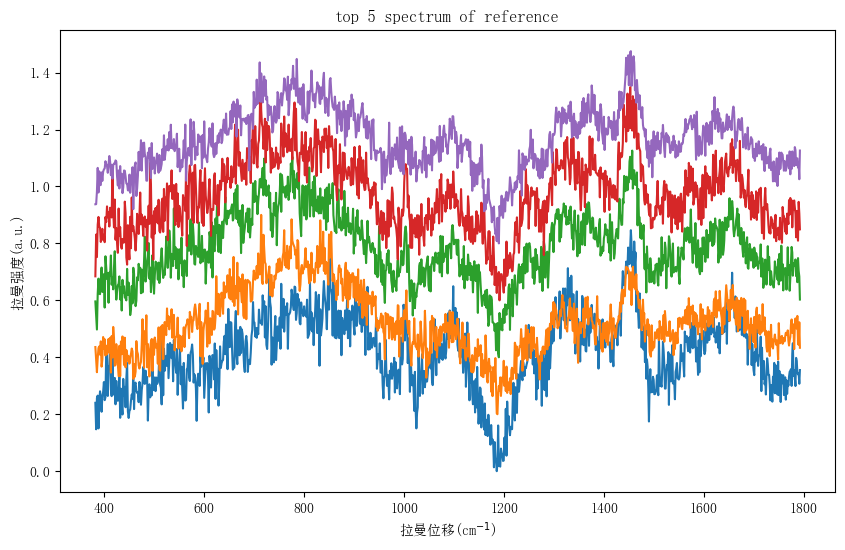

In [9]:
figure(x, y_reference[:5], 'top 5 spectrum of reference',  dy=0.2)

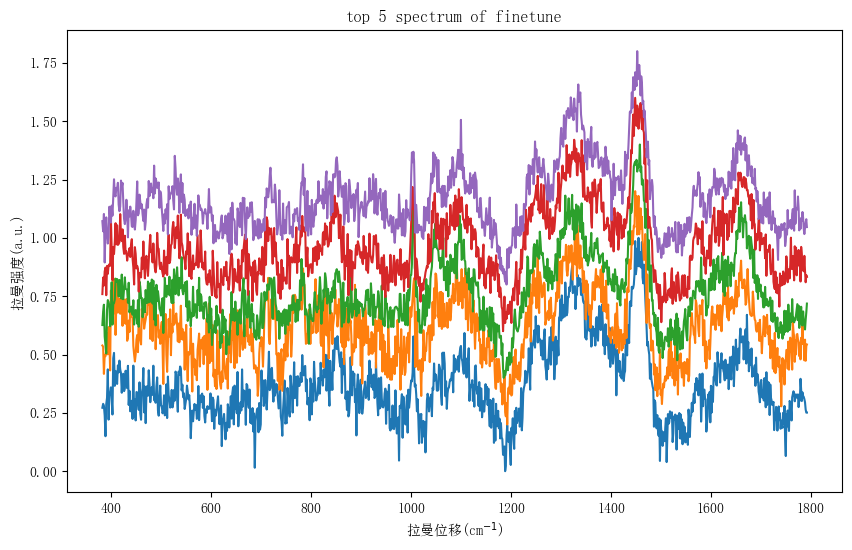

In [14]:
figure(x, y_finetune[:5], 'top 5 spectrum of finetune', dy=0.2)

In [11]:
z_finetune[:5]

array([0., 0., 0., 0., 0.])

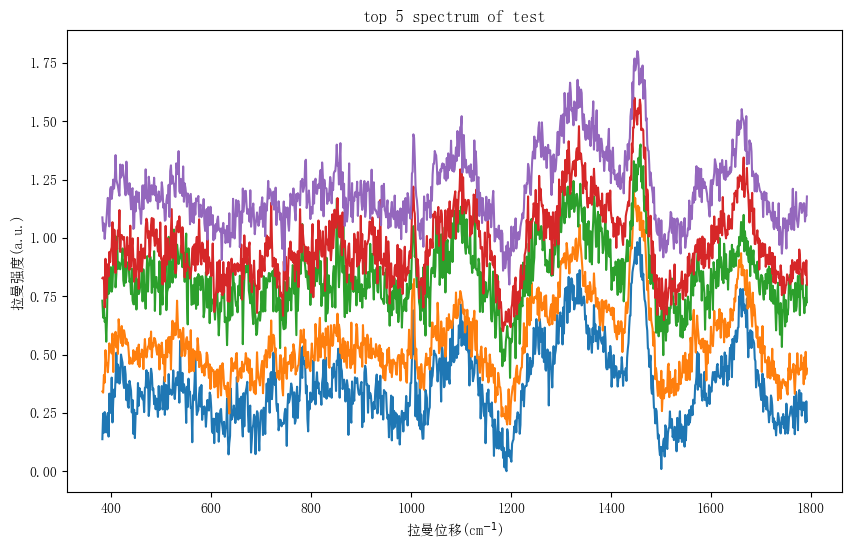

In [17]:
figure(x, y_test[:5], 'top 5 spectrum of test', dy=0.2)

In [ ]:
** 
作业：
    3）用自己创建的CNN模型，用finetune数据集进行训练和预测，使预测准确率达到80%以上。